# Week 5 - Advanced Models
- LightGMB, XGBoost, and hyperparameter tuning

- NOTE: for future use, added a validation set but as the LightGBM has already been trained on the data below so only validation set is used on XGBoost and will be used from here on out

In [7]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import random

np.random.seed(42)
random.seed(42)

done


In [109]:
# loading in feature engineered data
filepath = r"C:\Users\julia\downloads\IDX_summer_internship"

train_df = pd.read_csv(filepath + r"\train_enriched.csv", low_memory=False)
test_df = pd.read_csv(filepath + r"\test_enriched.csv", low_memory=False)

#making sure data leagake features are removed
drop_cols = [
    "CloseDate", "ListPrice", "OriginalListPrice",
    "ListingKey", "ListingKeyNumeric", "DaysOnMarket",
    "HighSchoolDistrict", "DistrictName", "DistrictMedianPrice",
    "Latitude_orig", "Longitude_orig"
]

x_train = train_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
x_test = test_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
y_train = train_df["ClosePrice"]
y_test = test_df["ClosePrice"]

# drop any remaining object columns
obj_cols = x_train.select_dtypes(include="object").columns.tolist()
if obj_cols:
    print(f"Dropping object columns: {obj_cols}")
    x_train = x_train.drop(columns=obj_cols)
    x_test = x_test.drop(columns=obj_cols)

# filter to CA only 
if 'StateOrProvince_CA' in x_train.columns:
    before = len(x_train)
    ca_mask = x_train['StateOrProvince_CA'] == 1
    x_train = x_train[ca_mask]
    y_train = y_train[ca_mask]
    print(f"Removed {before - len(x_train)} non-CA rows from training data")
    print(f"X_train after CA filter: {x_train.shape}")

# drop StateOrProvince columns 
state_cols = [col for col in x_train.columns if col.startswith('StateOrProvince')]
x_train = x_train.drop(columns=state_cols)
x_test = x_test.drop(columns=state_cols)
print(f"X_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")


Removed 20 non-CA rows from training data
X_train after CA filter: (315663, 52)
X_train: (315663, 40)
X_test: (12634, 40)


In [31]:
# evaluation function for metrics from before
def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"Model": label, "R2": r2, "RMSE": rmse, "MAE": mae, "MAPE": mape, "MdAPE": mdape}

In [33]:
# cleaning the names of some of the data columns for function with LightGMB
import re

def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

x_train = clean_col_names(x_train)
x_test = clean_col_names(x_test)

print("Column names cleaned")
print(x_train.columns.tolist())

Column names cleaned
['ViewYN', 'PoolPrivateYN', 'Latitude', 'Longitude', 'LivingArea', 'AttachedGarageYN', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet', 'Levels_MULTISPLIT_ONE', 'Levels_ONE', 'Levels_ONE_MULTISPLIT', 'Levels_ONE_THREEORMORE', 'Levels_ONE_TWO', 'Levels_ONE_TWO_MULTISPLIT', 'Levels_ONE_TWO_THREEORMORE', 'Levels_ONE_TWO_THREEORMORE_MULTISPLIT', 'Levels_THREEORMORE', 'Levels_THREEORMORE_MULTISPLIT', 'Levels_THREEORMORE_ONE', 'Levels_TWO', 'Levels_TWO_MULTISPLIT', 'Levels_TWO_ONE', 'Levels_TWO_THREEORMORE', 'Levels_TWO_THREEORMORE_MULTISPLIT', 'BedBathRatio', 'PropertyAge', 'AreaPerBedroom', 'DistrictEncoded']


In [18]:
# default LightGBM (no tuning)

lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1)
lgbm.fit(x_train, y_train)
y_pred_lgbm = lgbm.predict(x_test)
results_lgbm_default = evaluate_model(y_test, y_pred_lgbm, label="LightGBM (default)")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3051
[LightGBM] [Info] Number of data points in the train set: 315683, number of used features: 36
[LightGBM] [Info] Start training from score 1180371.483359

LightGBM (default)
R²:    0.8540
RMSE:  $345,872
MAE:   $199,688
MAPE:  16.80%
MdAPE: 12.00%


In [22]:
# Manually tuning some of the parameters to get a start on early stopping
extra_combos = [
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 1000, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 7, "learning_rate": 0.1},
]

for params in extra_combos:
    print(f"Trying: {params}")
    model = lgb.LGBMRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        random_state=42,
        n_jobs=-1
    )
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print(f"  R²: {r2:.4f} | MdAPE: {mdape:.2f}%")

Trying: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033379 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3051
[LightGBM] [Info] Number of data points in the train set: 315683, number of used features: 36
[LightGBM] [Info] Start training from score 1180371.483359
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [39]:
#running until we see no more improvement -> working on n_estimators (basically allowing early stopping)
lgbm_es3 = lgb.LGBMRegressor(
    n_estimators=3000, #max number of trees to build - set high to allow for early stopping
    max_depth=7, #how deep each tree can go
    learning_rate=0.05, # how much each new tree contributes to the final prediction
    random_state=42,
    n_jobs=-1
)

#fitting params
lgbm_es3.fit(
    x_train_sub, y_train_sub,
    eval_set=[(x_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), #checks for improvement every 50 consecutive trees if no then stop
               lgb.log_evaluation(300)]
)

print(f"\nBest number of trees: {lgbm_es3.best_iteration_}")
y_pred_es3 = lgbm_es3.predict(x_test)
results_es3 = evaluate_model(y_test, y_pred_es3, label="LightGBM (early stopping 3000)")

C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3052
[LightGBM] [Info] Number of data points in the train set: 284096, number of used features: 35
[LightGBM] [Info] Start training from score 1179758.801420
Training until validation scores don't improve for 50 rounds
[300]	valid_0's l2: 1.05185e+11
[600]	valid_0's l2: 9.16812e+10
[900]	valid_0's l2: 8.59907e+10
[1200]	valid_0's l2: 8.25816e+10
[1500]	valid_0's l2: 8.02135e+10
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1800]	valid_0's l2: 7.85784e+10
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[2100]	valid_0's l2: 7.74138e+10
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [43]:
#trying some manual tuning again after early stopping above 
param_combos = [
    {"num_leaves": 63, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"num_leaves": 127, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"num_leaves": 63, "min_child_samples": 50, "subsample": 0.7, "colsample_bytree": 0.7},
    {"num_leaves": 127, "min_child_samples": 50, "subsample": 0.9, "colsample_bytree": 0.9},
]

for params in param_combos:
    print(f"Trying: {params}")
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        max_depth=7,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        **params
    )
    model.fit(
        x_train_sub, y_train_sub,
        eval_set=[(x_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50),
                   lgb.log_evaluation(500)]
    )
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print(f"  Best trees: {model.best_iteration_} | R²: {r2:.4f} | MdAPE: {mdape:.2f}%\n")

Trying: {'num_leaves': 63, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8}


C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3052
[LightGBM] [Info] Number of data points in the train set: 284096, number of used features: 35
[LightGBM] [Info] Start training from score 1179758.801420
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.228762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3052
[LightGBM] [Info] Number of data points in the train set: 284096, number of used features: 35
[LightGBM] [Info] Start training from score 1179758.801420
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.049699 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3048
[LightGBM] [Info] Number of data points in the train set: 284096, number of used features: 33
[LightGBM] [Info] Start training from score 1179758.801420
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025639 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3048
[LightGBM] [Info] Number of data points in the train set: 284096, number of used features: 33
[LightGBM] [Info] Start training from score 1179758.801420
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [60]:
# retraining LGMB with the tuned paramaters we got from above and now 3000 estimators

lgbm_final = lgb.LGBMRegressor(
    n_estimators=3000,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
lgbm_final.fit(x_train, y_train)
y_pred_final = lgbm_final.predict(x_test)
results_lgbm_final = evaluate_model(y_test, y_pred_final, label="LightGBM (tuned)")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041845 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3051
[LightGBM] [Info] Number of data points in the train set: 315663, number of used features: 35
[LightGBM] [Info] Start training from score 1180388.788142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [58]:
# retrain random forest with CA-only data to see if it has an impact on the results we are getting above
from sklearn.ensemble import RandomForestRegressor
rf_ca = RandomForestRegressor(n_estimators=100, max_depth=15, 
                               random_state=42, n_jobs=-1)
rf_ca.fit(x_train, y_train)
y_pred_rf_ca = rf_ca.predict(x_test)
results_rf_ca = evaluate_model(y_test, y_pred_rf_ca, 
                                label="Random Forest (CA only, engineered)")

# compare to previous
print(f"\nPrevious RF (with non-CA): R²=0.8920, MdAPE=7.95%")


Random Forest (CA only, engineered)
R²:    0.8826
RMSE:  $310,122
MAE:   $166,360
MAPE:  13.17%
MdAPE: 8.88%

Previous RF (with non-CA): R²=0.8920, MdAPE=7.95%


In [73]:
comparison = pd.DataFrame([results_lr, results_dt, results_rf, results_rf_ca, results_lgbm])
comparison = comparison.set_index("Model")

comparison["R2"] = comparison["R2"].map("{:.4f}".format)
comparison["RMSE"] = comparison["RMSE"].map("${:,.0f}".format)
comparison["MAE"] = comparison["MAE"].map("${:,.0f}".format)
comparison["MAPE"] = comparison["MAPE"].map("{:.2f}%".format)
comparison["MdAPE"] = comparison["MdAPE"].map("{:.2f}%".format)

comparison.columns = ["R²", "RMSE", "MAE", "MAPE", "MdAPE"]
comparison.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt',
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'center'),
              ('font-size', '12pt'),
              ('font-weight', 'bold')]
}])

,R²,RMSE,MAE,MAPE,MdAPE
Model,,,,,
Linear Regression,0.4787,"$653,574","$436,431",43.73%,30.42%
Decision Tree,0.7814,"$423,219","$242,696",19.73%,13.87%
Random Forest,0.8806,"$312,748","$167,504",13.20%,8.95%
Random Forest (CA only),0.8826,"$310,122","$166,360",13.17%,8.88%
LightGBM (tuned),0.9078,"$274,801","$148,945",11.84%,8.21%


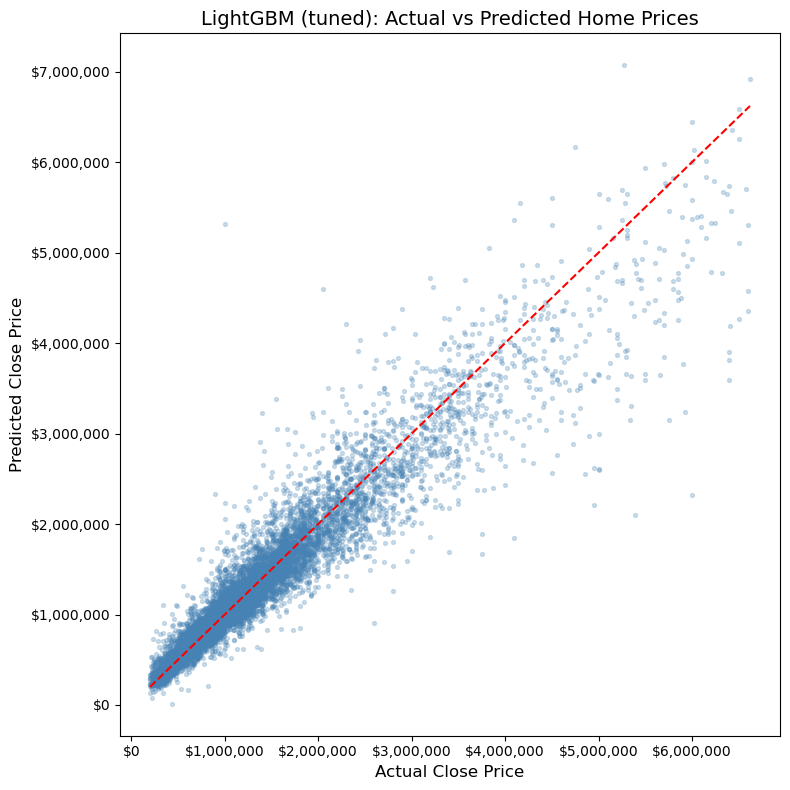

In [75]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_final, alpha=0.25, s=8, color='steelblue')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Actual Close Price", fontsize=12)
ax.set_ylabel("Predicted Close Price", fontsize=12)
ax.set_title("LightGBM (tuned): Actual vs Predicted Home Prices", fontsize=14)
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.savefig(filepath + r"\lgbm_predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()

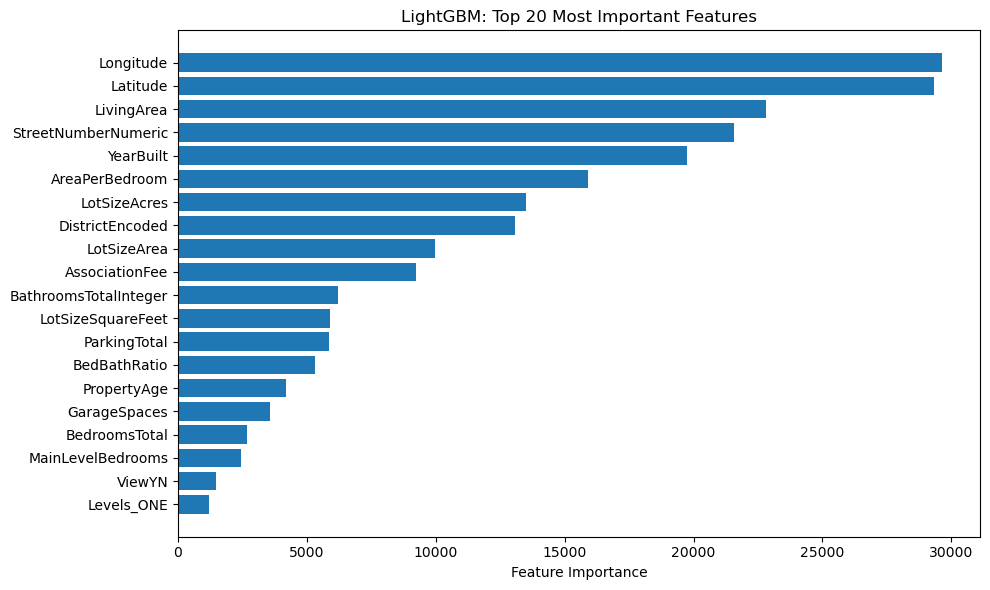

                  Feature  Importance
3               Longitude       29631
2                Latitude       29315
4              LivingArea       22820
9     StreetNumberNumeric       21586
8               YearBuilt       19727
38         AreaPerBedroom       15904
7            LotSizeAcres       13487
39        DistrictEncoded       13079
14            LotSizeArea        9989
18         AssociationFee        9223
10  BathroomsTotalInteger        6189
19      LotSizeSquareFeet        5896
6            ParkingTotal        5865
36           BedBathRatio        5309
37            PropertyAge        4191
17           GarageSpaces        3583
11          BedroomsTotal        2672
15      MainLevelBedrooms        2453
0                  ViewYN        1469
21             Levels_ONE        1212


In [68]:
# feature importance - LightGBM

importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": lgbm_final.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("LightGBM: Top 20 Most Important Features")
plt.tight_layout()
plt.savefig(filepath + r"\lgbm_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print(importance_df)

# Trying XGBoost and creating a data validation set

In [86]:
import xgboost as xgb

# imported function from week 2 preprocessing
def make_train_test_split(df, date_col='CloseDate', x_months=12):
    """
    Creates a time-based train/test split.
    
    Parameters:
        df: cleaned dataframe
        date_col: name of the date column to split on
        x_months: number of months to use for training window (tunable)
    
    Returns:
        train_df, test_df
    """
    df[date_col] = pd.to_datetime(df[date_col], format='mixed')
    
    latest_month = df[date_col].dt.to_period('M').max()
    cutoff_month = latest_month - x_months
    
    test_df = df[df[date_col].dt.to_period('M') == latest_month].copy()
    train_df = df[
        (df[date_col].dt.to_period('M') > cutoff_month) &
        (df[date_col].dt.to_period('M') < latest_month)
    ].copy()
    
    print(f"Test month: {latest_month}")
    print(f"Training window: {x_months} months ({cutoff_month} to {latest_month})")
    print(f"Training rows: {len(train_df):,}")
    print(f"Testing rows:  {len(test_df):,}")
    
    return train_df, test_df

# reload enriched data
train_full = pd.read_csv(filepath + r"\train_enriched.csv", low_memory=False)
train_full["CloseDate"] = pd.to_datetime(train_full["CloseDate"], errors="coerce")

train_df, test_df = make_train_test_split(train_full, x_months=30)

# carve validation month out of training data
val_month = train_df["CloseDate"].dt.to_period("M").max()
val_df = train_df[train_df["CloseDate"].dt.to_period("M") == val_month].copy()
train_df = train_df[train_df["CloseDate"].dt.to_period("M") < val_month].copy()

print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Test month: 2026-05
Training window: 30 months (2023-11 to 2026-05)
Training rows: 303,839
Testing rows:  11,844
Train: 292,001 rows
Val:   11,838 rows
Test:  11,844 rows


In [88]:
# cleaning the data and making x and y (_v added for validation split to avoid using the same data twice)

drop_cols = [
    "CloseDate", "ListPrice", "OriginalListPrice",
    "ListingKey", "ListingKeyNumeric", "DaysOnMarket",
    "HighSchoolDistrict", "DistrictName", "DistrictMedianPrice",
    "Latitude_orig", "Longitude_orig"
]

x_train_v = train_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
x_val_v   = val_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
x_test_v  = test_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")

y_train_v = train_df["ClosePrice"]
y_val_v   = val_df["ClosePrice"]
y_test_v  = test_df["ClosePrice"]

# drop object columns
for df in [x_train_v, x_val_v, x_test_v]:
    obj_cols = df.select_dtypes(include="object").columns.tolist()
    for col in obj_cols:
        df.drop(columns=col, inplace=True)

# filter to CA only
if "StateOrProvince_CA" in x_train_v.columns:
    ca_mask = x_train_v["StateOrProvince_CA"] == 1
    x_train_v = x_train_v[ca_mask]
    y_train_v = y_train_v[ca_mask]

# drop state columns
state_cols = [col for col in x_train_v.columns if col.startswith("StateOrProvince")]
x_train_v = x_train_v.drop(columns=state_cols, errors="ignore")
x_val_v   = x_val_v.drop(columns=state_cols, errors="ignore")
x_test_v  = x_test_v.drop(columns=state_cols, errors="ignore")

# clean column names for XGBoost
import re
def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

x_train_v = clean_col_names(x_train_v)
x_val_v   = clean_col_names(x_val_v)
x_test_v  = clean_col_names(x_test_v)

print(f"X_train: {x_train_v.shape}")
print(f"X_val:   {x_val_v.shape}")
print(f"X_test:  {x_test_v.shape}")

X_train: (291982, 40)
X_val:   (11838, 40)
X_test:  (11844, 40)


In [90]:
# first run of XGBoost, allowing early stopping every 50 rounds
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=3000,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric="rmse"
)

xgb_model.fit(
    x_train_v, y_train_v,
    eval_set=[(x_val_v, y_val_v)],
    verbose=100
)

print(f"\nBest iteration: {xgb_model.best_iteration}")
y_pred_xgb = xgb_model.predict(x_test_v)
results_xgb = evaluate_model(y_test_v, y_pred_xgb, label="XGBoost (early stopping)")

[0]	validation_0-rmse:897962.27656
[100]	validation_0-rmse:354953.79442
[200]	validation_0-rmse:325336.28727
[300]	validation_0-rmse:312585.38786
[400]	validation_0-rmse:304324.85211
[500]	validation_0-rmse:299193.22886
[600]	validation_0-rmse:295742.88780
[700]	validation_0-rmse:292730.19604
[800]	validation_0-rmse:290016.52454
[900]	validation_0-rmse:287891.19462
[1000]	validation_0-rmse:286275.07369
[1100]	validation_0-rmse:285105.02339
[1200]	validation_0-rmse:283930.84849
[1300]	validation_0-rmse:282812.58677
[1400]	validation_0-rmse:282174.39599
[1500]	validation_0-rmse:281219.54741
[1600]	validation_0-rmse:280720.23510
[1700]	validation_0-rmse:280147.76602
[1800]	validation_0-rmse:279790.12898
[1900]	validation_0-rmse:279295.80349
[2000]	validation_0-rmse:278802.25973
[2100]	validation_0-rmse:278513.90384
[2200]	validation_0-rmse:278404.99419
[2300]	validation_0-rmse:278240.48660
[2400]	validation_0-rmse:277977.83623
[2500]	validation_0-rmse:277632.77530
[2600]	validation_0-rmse

In [92]:
#manual tuning based on early stopping above
param_combos = [
    {"max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 7, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 7, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.6},
    {"max_depth": 7, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 9, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
]

tuning_results = []

for params in param_combos:
    print(f"Trying: {params}")
    model = xgb.XGBRegressor(
        n_estimators=3000,
        early_stopping_rounds=50,
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1,
        **params
    )
    model.fit(
        x_train_v, y_train_v,
        eval_set=[(x_val_v, y_val_v)],
        verbose=False
    )
    y_pred = model.predict(x_test_v)
    r2 = r2_score(y_test_v, y_pred)
    mdape = np.median(np.abs((y_test_v - y_pred) / y_test_v)) * 100
    print(f"  Best trees: {model.best_iteration} | R²: {r2:.4f} | MdAPE: {mdape:.2f}%")
    tuning_results.append({**params, "best_trees": model.best_iteration, 
                           "R2": r2, "MdAPE": mdape})

tuning_df = pd.DataFrame(tuning_results)
print("\n--- XGBoost Tuning Results ---")
print(tuning_df.sort_values("MdAPE"))

Trying: {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best trees: 2999 | R²: 0.8995 | MdAPE: 9.05%
Trying: {'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best trees: 2958 | R²: 0.9080 | MdAPE: 8.19%
Trying: {'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.6}
  Best trees: 2212 | R²: 0.9069 | MdAPE: 8.43%
Trying: {'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best trees: 2999 | R²: 0.9058 | MdAPE: 8.41%
Trying: {'max_depth': 9, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best trees: 1639 | R²: 0.9088 | MdAPE: 7.93%

--- XGBoost Tuning Results ---
   max_depth  learning_rate  subsample  colsample_bytree  best_trees  \
4          9           0.05        0.8               0.8        1639   
1          7           0.05        0.8               0.8        2958   
3          7           0.03        0.8               0.8      

In [94]:
# trying more manually with max depth = 9 from above
param_combos_2 = [
    {"max_depth": 9, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.8},
    {"max_depth": 9, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.9},
    {"max_depth": 9, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 11, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
]

for params in param_combos_2:
    print(f"Trying: {params}")
    model = xgb.XGBRegressor(
        n_estimators=3000,
        early_stopping_rounds=50,
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1,
        **params
    )
    model.fit(
        x_train_v, y_train_v,
        eval_set=[(x_val_v, y_val_v)],
        verbose=False
    )
    y_pred = model.predict(x_test_v)
    r2 = r2_score(y_test_v, y_pred)
    mdape = np.median(np.abs((y_test_v - y_pred) / y_test_v)) * 100
    print(f"  Best trees: {model.best_iteration} | R²: {r2:.4f} | MdAPE: {mdape:.2f}%")

Trying: {'max_depth': 9, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.8}
  Best trees: 1319 | R²: 0.9098 | MdAPE: 8.05%
Trying: {'max_depth': 9, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.9}
  Best trees: 1504 | R²: 0.9090 | MdAPE: 7.90%
Trying: {'max_depth': 9, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best trees: 2101 | R²: 0.9096 | MdAPE: 7.82%
Trying: {'max_depth': 11, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best trees: 917 | R²: 0.9074 | MdAPE: 7.69%


In [96]:
# some more manual tuning using the above parameters - seeing if the MdAPE can be improved
param_combos_3 = [
    {"max_depth": 11, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.9},
    {"max_depth": 11, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.8},
    {"max_depth": 11, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 13, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
]

for params in param_combos_3:
    print(f"Trying: {params}")
    model = xgb.XGBRegressor(
        n_estimators=3000,
        early_stopping_rounds=50,
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1,
        **params
    )
    model.fit(
        x_train_v, y_train_v,
        eval_set=[(x_val_v, y_val_v)],
        verbose=False
    )
    y_pred = model.predict(x_test_v)
    r2 = r2_score(y_test_v, y_pred)
    mdape = np.median(np.abs((y_test_v - y_pred) / y_test_v)) * 100
    print(f"  Best trees: {model.best_iteration} | R²: {r2:.4f} | MdAPE: {mdape:.2f}%")

Trying: {'max_depth': 11, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.9}
  Best trees: 764 | R²: 0.9083 | MdAPE: 7.72%
Trying: {'max_depth': 11, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.8}
  Best trees: 1029 | R²: 0.9070 | MdAPE: 7.66%
Trying: {'max_depth': 11, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best trees: 1443 | R²: 0.9087 | MdAPE: 7.66%
Trying: {'max_depth': 13, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best trees: 463 | R²: 0.9044 | MdAPE: 7.69%


In [98]:
# training final model of XGBoost
xgb_final = xgb.XGBRegressor(
    n_estimators=3000,
    max_depth=11,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    x_train_v, y_train_v,
    eval_set=[(x_val_v, y_val_v)],
    verbose=False
)

print(f"Best trees: {xgb_final.best_iteration}")
y_pred_xgb_final = xgb_final.predict(x_test_v)
results_xgb_final = evaluate_model(y_test_v, y_pred_xgb_final, 
                                    label="XGBoost (tuned)")

Best trees: 1029

XGBoost (tuned)
R²:    0.9070
RMSE:  $279,826
MAE:   $147,190
MAPE:  11.19%
MdAPE: 7.66%


In [104]:
#comparison table
results_lr =       {"Model": "Linear Regression",             "R2": 0.4787, "RMSE": 653574, "MAE": 436431, "MAPE": 43.73, "MdAPE": 30.42}
results_dt =       {"Model": "Decision Tree",                 "R2": 0.7814, "RMSE": 423219, "MAE": 242696, "MAPE": 19.73, "MdAPE": 13.87}
results_rf =       {"Model": "Random Forest",                 "R2": 0.8806, "RMSE": 312748, "MAE": 167504, "MAPE": 13.20, "MdAPE": 8.95}
results_rf_ca =    {"Model": "Random Forest (CA only)",       "R2": 0.8826, "RMSE": 310122, "MAE": 166360, "MAPE": 13.17, "MdAPE": 8.88}
results_lgbm =     {"Model": "LightGBM (tuned)",              "R2": 0.9078, "RMSE": 274801, "MAE": 148945, "MAPE": 11.84, "MdAPE": 8.21}
results_xgb =      {"Model": "XGBoost (tuned)",               "R2": 0.9070, "RMSE": 279826, "MAE": 147190, "MAPE": 11.19, "MdAPE": 7.66}

comparison = pd.DataFrame([
    results_lr, results_dt, results_rf, results_rf_ca, results_lgbm, results_xgb
])
comparison = comparison.set_index("Model")
comparison["R2"]    = comparison["R2"].map("{:.4f}".format)
comparison["RMSE"]  = comparison["RMSE"].map("${:,.0f}".format)
comparison["MAE"]   = comparison["MAE"].map("${:,.0f}".format)
comparison["MAPE"]  = comparison["MAPE"].map("{:.2f}%".format)
comparison["MdAPE"] = comparison["MdAPE"].map("{:.2f}%".format)
comparison.columns = ["R²", "RMSE", "MAE", "MAPE", "MdAPE"]
comparison.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt',
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'center'),
              ('font-size', '12pt'),
              ('font-weight', 'bold')]
}])

,R²,RMSE,MAE,MAPE,MdAPE
Model,,,,,
Linear Regression,0.4787,"$653,574","$436,431",43.73%,30.42%
Decision Tree,0.7814,"$423,219","$242,696",19.73%,13.87%
Random Forest,0.8806,"$312,748","$167,504",13.20%,8.95%
Random Forest (CA only),0.8826,"$310,122","$166,360",13.17%,8.88%
LightGBM (tuned),0.9078,"$274,801","$148,945",11.84%,8.21%
XGBoost (tuned),0.9070,"$279,826","$147,190",11.19%,7.66%


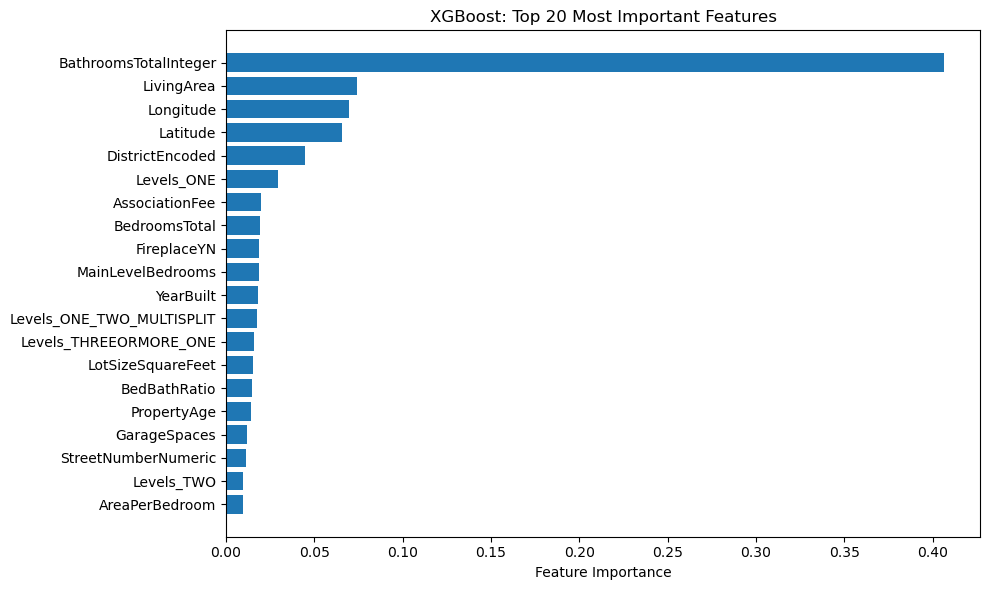

                      Feature  Importance
10      BathroomsTotalInteger    0.406457
4                  LivingArea    0.074138
3                   Longitude    0.069528
2                    Latitude    0.065612
39            DistrictEncoded    0.044627
21                 Levels_ONE    0.029168
18             AssociationFee    0.019761
11              BedroomsTotal    0.019314
12                FireplaceYN    0.018907
15          MainLevelBedrooms    0.018522
8                   YearBuilt    0.018127
25  Levels_ONE_TWO_MULTISPLIT    0.017396
30     Levels_THREEORMORE_ONE    0.016040
19          LotSizeSquareFeet    0.015294
36               BedBathRatio    0.014815
37                PropertyAge    0.014189
17               GarageSpaces    0.011873
9         StreetNumberNumeric    0.011274
31                 Levels_TWO    0.009742
38             AreaPerBedroom    0.009741


In [106]:
#feature importance
importance_df = pd.DataFrame({
    "Feature": x_train_v.columns,
    "Importance": xgb_final.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("XGBoost: Top 20 Most Important Features")
plt.tight_layout()
plt.savefig(filepath + r"\xgb_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print(importance_df)